In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d deadskull7/fer2013

In [ ]:
!unzip fer2013.zip
!rm fer2013.zip

Archive:  fer2013.zip
  inflating: fer2013.csv             


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
import cv2

In [ ]:
data = data = pd.read_csv('fer2013.csv')
#check data shape
data.shape

(35887, 3)

In [ ]:
data.head(10)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
5,2,55 55 55 55 55 54 60 68 54 85 151 163 170 179 ...,Training
6,4,20 17 19 21 25 38 42 42 46 54 56 62 63 66 82 1...,Training
7,3,77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...,Training
8,3,85 84 90 121 101 102 133 153 153 169 177 189 1...,Training
9,2,255 254 255 254 254 179 122 107 95 124 149 150...,Training


In [ ]:
emotion_map = {0: 'Angry', 1: 'Digust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
emotion_counts = data['emotion'].value_counts(sort=False).reset_index()
emotion_counts.columns = ['emotion', 'number']
emotion_counts['emotion'] = emotion_counts['emotion'].map(emotion_map)
emotion_counts

,emotion,number
0,Angry,4953
1,Fear,5121
2,Sad,6077
3,Neutral,6198
4,Happy,8989
5,Surprise,4002
6,Digust,547


In [ ]:
data.Usage.value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


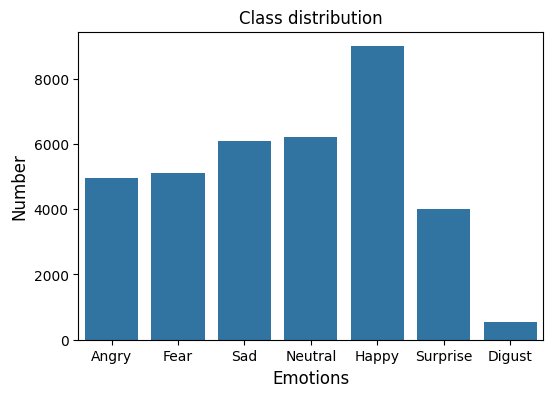

In [ ]:

plt.figure(figsize=(6,4))
sns.barplot(x = emotion_counts.emotion, y = emotion_counts.number)
plt.title('Class distribution')
plt.ylabel('Number', fontsize=12)
plt.xlabel('Emotions', fontsize=12)
plt.show()

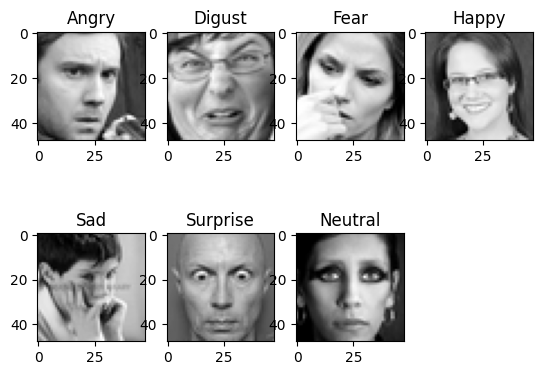

In [ ]:
def row2image(row):
    pixels, emotion = row['pixels'], emotion_map[row['emotion']]
    img = np.array(pixels.split())
    img = img.reshape(48,48)
    return img.astype(np.uint8), emotion  # Return grayscale image and emotion as a tuple

# plt.figure(0, figsize=(16,10))
for i in range(1,8):
    face = data[data['emotion'] == i-1].iloc[0]
    img, emotion = row2image(face)  # Extract grayscale image and emotion
    plt.subplot(2,4,i)
    plt.imshow(img, cmap='gray')  # Display grayscale image
    plt.title(emotion)  # Set emotion as title

plt.show()

In [ ]:
#split data into training, validation and test set
data_train = data[data['Usage']=='Training'].copy()
data_val   = data[data['Usage']=='PublicTest'].copy()
data_test  = data[data['Usage']=='PrivateTest'].copy()
print("train shape: {}, \nvalidation shape: {}, \ntest shape: {}".format(data_train.shape, data_val.shape, data_test.shape))

train shape: (28709, 3), 
validation shape: (3589, 3), 
test shape: (3589, 3)


In [ ]:
# CRNO stands for Convert, Reshape, Normalize, One-hot encoding
def CRNO(df, dataName, width, height, num_classes):
    def convert_to_list(pixel_sequence):
        if isinstance(pixel_sequence, list):
            return pixel_sequence
        return [int(pixel) for pixel in pixel_sequence.split()]

    df['pixels'] = df['pixels'].apply(convert_to_list)
    data_X = np.array(df['pixels'].tolist(), dtype='float32').reshape(-1, width, height, 1) / 255.0
    data_Y = to_categorical(df['emotion'], num_classes)
    print(f"{dataName}_X shape: {data_X.shape}, {dataName}_Y shape: {data_Y.shape}")
    return data_X, data_Y

# Example usage:
width, height = 48, 48
num_classes = 7

# Assuming data_train, data_val, and data_test are already loaded DataFrames
train_X, train_Y = CRNO(data_train, "train", width, height, num_classes) # training data
val_X, val_Y = CRNO(data_val, "val", width, height, num_classes)         # validation data
test_X, test_Y = CRNO(data_test, "test", width, height, num_classes)     # test data

train_X shape: (28709, 48, 48, 1), train_Y shape: (28709, 7)
val_X shape: (3589, 48, 48, 1), val_Y shape: (3589, 7)
test_X shape: (3589, 48, 48, 1), test_Y shape: (3589, 7)


In [ ]:
import tensorflow as tf

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = tf.keras.layers.Dense(units, activation=tf.nn.gelu)(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

def create_optimized_CCT(
    image_size=48,
    num_classes=7,
    embedding_dim=128,
    transformer_layers=6,
    num_heads=4,
    mlp_dim=256,
    dropout_rate=0.2,
):
    inputs = tf.keras.Input(shape=(image_size, image_size, 1))

    # --- Convolutional Tokenizer ---
    x = tf.keras.layers.Conv2D(embedding_dim, 3, strides=2, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv2D(embedding_dim, 3, strides=2, padding="same", activation="relu")(x)

    # Convert to sequence of tokens
    seq_len = (image_size // 4) ** 2
    x = tf.keras.layers.Reshape((seq_len, embedding_dim))(x)

    # Create learnable positional embeddings
    pos_embed = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=embedding_dim)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    x = x + pos_embed(positions)

    # --- Transformer Encoder ---
    for _ in range(transformer_layers):

        # Pre-LN (important!)
        x_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

        # Multi-head self-attention
        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embedding_dim, dropout=dropout_rate
        )(x_norm, x_norm)
        x = tf.keras.layers.Add()([x, attn_output])

        # MLP block
        x_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
        mlp_output = mlp(x_norm, [mlp_dim, embedding_dim], dropout_rate)
        x = tf.keras.layers.Add()([x, mlp_output])

    # --- Sequence Pooling ---
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # --- Output layer ---
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
        loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"],
    )

    return model

model = create_optimized_CCT()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 24,    │      1,280 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 12, 12,    │    147,584 │ conv2d[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 144, 128)  │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 144, 128)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 144, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 144, 128)  │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 144, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 144, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 144, 128)  │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 144, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 144, 128)  │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 144, 128)  │          0 │ add_2[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 144, 256)  │     33,024 │ layer_normalizat

 Total params: 2,131,207 (8.13 MB)

 Trainable params: 2,131,207 (8.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

datagen.fit(train_X)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10, monitor="val_loss", restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
history = model.fit(
    datagen.flow(train_X, train_Y, batch_size=64),
    validation_data=(val_X, val_Y),
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 84s 97ms/step - accuracy: 0.2173 - loss: 1.9279 - val_accuracy: 0.2502 - val_loss: 1.8800 - learning_rate: 1.0000e-04
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2560 - loss: 1.8316 - val_accuracy: 0.2784 - val_loss: 1.8523 - learning_rate: 1.0000e-04
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.2725 - loss: 1.8036 - val_accuracy: 0.3204 - val_loss: 1.7646 - learning_rate: 1.0000e-04
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.2993 - loss: 1.7755 - val_accuracy: 0.3405 - val_loss: 1.7867 - learning_rate: 1.0000e-04
Epoch 5/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3157 - loss: 1.7472 - val_accuracy: 0.3644 - val_loss: 1.7147 - learning_rate: 1.0000e-04
Epoch 6/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3381 - loss: 1.7263 - val_accuracy: 0.3739 - val_loss: 1.6837 - learning_rate: 1.0000e-04
Epoch 7/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - a

In [ ]:
test_loss, test_acc = model.evaluate(test_X, test_Y)
print("Test Accuracy:", test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4955 - loss: 1.5318
Test Accuracy: 0.4984675347805023


113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step


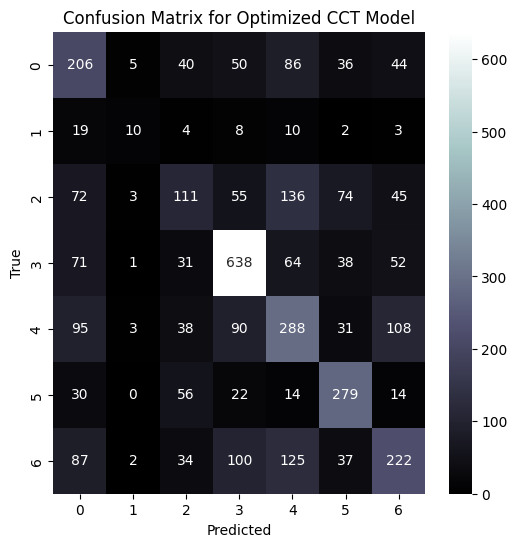

Classification Report for Optimized CCT Model:
               precision    recall  f1-score   support

           0       0.36      0.44      0.39       467
           1       0.42      0.18      0.25        56
           2       0.35      0.22      0.27       496
           3       0.66      0.71      0.69       895
           4       0.40      0.44      0.42       653
           5       0.56      0.67      0.61       415
           6       0.45      0.37      0.41       607

    accuracy                           0.49      3589
   macro avg       0.46      0.43      0.43      3589
weighted avg       0.48      0.49      0.48      3589



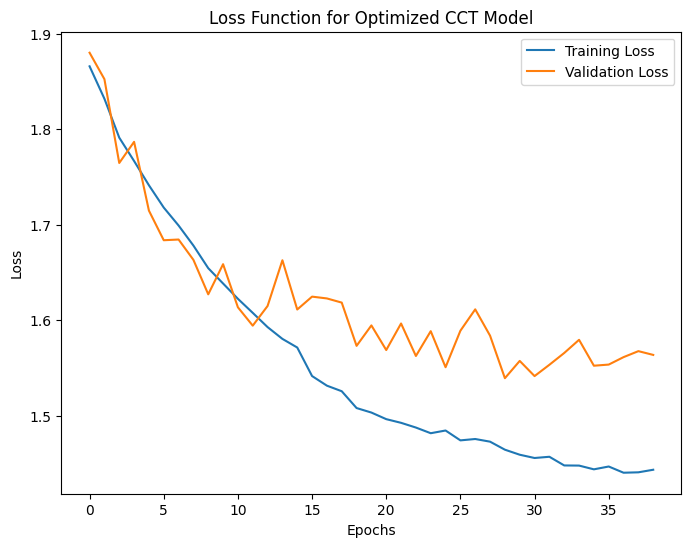

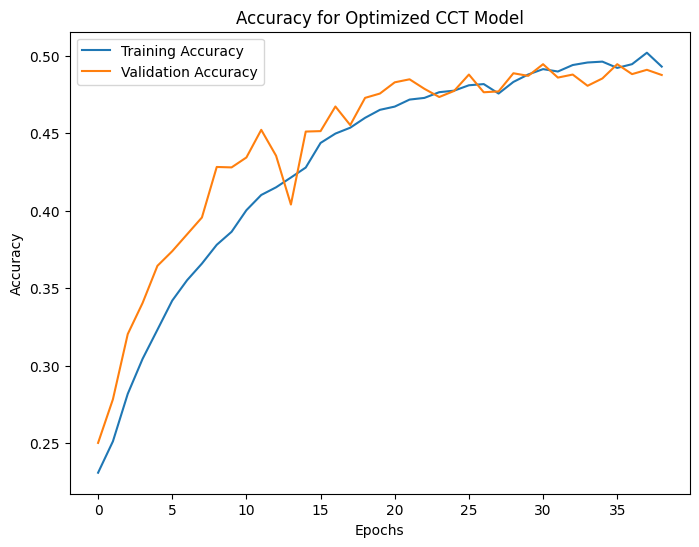

In [ ]:
# Predictions
# Predictions on validation set
val_pred = model.predict(val_X)                 # correct input
val_pred_labels = np.argmax(val_pred, axis=1)   # convert probabilities to class labels
y_true = np.argmax(val_Y, axis=1)               # convert one-hot to class labels

# Confusion Matrix and Classification Report
cm = confusion_matrix(y_true, val_pred_labels)
cr = classification_report(y_true, val_pred_labels)

# Plot Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='bone')
plt.title('Confusion Matrix for Optimized CCT Model')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Print classification report
print("Classification Report for Optimized CCT Model:\n", cr)

# Plot Loss Function Graph
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Function for Optimized CCT Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy Graph
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy for Optimized CCT Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
model.save("my_cct_model.keras")